# Notebook 03 — Tiền xử lý Dữ liệu (Preprocessing)
**Đề tài 7 — Nhóm 13 | 2025–2026**

---
Các bước tiền xử lý:
1. Loại bỏ bản ghi bất thường
2. Winsorize outlier (1% – 99%)
3. Label Encoding cho biến phân loại
4. Rời rạc hóa biến liên tục (cho Apriori)
5. Log-transform biến lệch


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

PROC = Path("../data/processed")
OUT  = Path("../outputs/figures"); OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / "crop_yield_main.csv")
print(f"Dữ liệu đầu vào: {df.shape[0]:,} dòng × {df.shape[1]} cột")
df.head(3)

Dữ liệu đầu vào: 28,242 dòng × 7 cột


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37


## 1. Kiểm tra và Loại bỏ bản ghi bất thường

In [2]:
before = len(df)
# Lọc năng suất phi lý
df = df[df["hg/ha_yield"] > 0].copy()
# Lọc lượng mưa âm
df = df[df["average_rain_fall_mm_per_year"] >= 0].copy()
# Lọc thuốc trừ sâu âm
df = df[df["pesticides_tonnes"] >= 0].copy()
# Lọc nhiệt độ ngoài khoảng hợp lý
df = df[df["avg_temp"].between(-10, 40)].copy()

print(f"Trước lọc : {before:,}")
print(f"Sau lọc   : {len(df):,}  (loại bỏ {before-len(df):,} bản ghi)")

# Missing
print(f"\nMissing sau lọc: {df.isnull().sum().to_dict()}")

Trước lọc : 28,242
Sau lọc   : 28,242  (loại bỏ 0 bản ghi)

Missing sau lọc: {'Area': 0, 'Item': 0, 'Year': 0, 'hg/ha_yield': 0, 'average_rain_fall_mm_per_year': 0, 'pesticides_tonnes': 0, 'avg_temp': 0}


## 2. Winsorize Outlier (1% – 99%)

In [3]:
def winsorize(series, low=0.01, high=0.99):
    lo, hi = series.quantile(low), series.quantile(high)
    return series.clip(lo, hi), lo, hi

cols_to_win = ["hg/ha_yield","pesticides_tonnes","average_rain_fall_mm_per_year"]
bounds = {}
for col in cols_to_win:
    df[col], lo, hi = winsorize(df[col])
    bounds[col] = {"lo": float(lo), "hi": float(hi)}
    print(f"  {col:40s}: [{lo:.2f}, {hi:.2f}]")
print(f"\nShape sau winsorize: {df.shape}")

  hg/ha_yield                             : [4336.79, 382592.00]
  pesticides_tonnes                       : [4.44, 345026.00]
  average_rain_fall_mm_per_year           : [51.00, 3240.00]

Shape sau winsorize: (28242, 7)


## 3. Label Encoding

In [4]:
le_area = LabelEncoder()
le_item = LabelEncoder()
df["Area_enc"] = le_area.fit_transform(df["Area"])
df["Item_enc"] = le_item.fit_transform(df["Item"])
print(f"Area: {len(le_area.classes_)} quốc gia encoded")
print(f"Item: {len(le_item.classes_)} loại cây encoded")
print(f"  Cây trồng: {list(le_item.classes_)}")

Area: 101 quốc gia encoded
Item: 10 loại cây encoded
  Cây trồng: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']


## 4. Rời rạc hóa biến liên tục (cho Apriori)

In [5]:
# Yield thành 3 mức Low/Medium/High theo quantile
q_yield = df["hg/ha_yield"].quantile([0.33, 0.67])
df["yield_cat"] = pd.cut(df["hg/ha_yield"],
    bins=[-np.inf, q_yield[0.33], q_yield[0.67], np.inf],
    labels=["Low","Medium","High"])

q_rain = df["average_rain_fall_mm_per_year"].quantile([0.33, 0.67])
df["rain_cat"] = pd.cut(df["average_rain_fall_mm_per_year"],
    bins=[-np.inf, q_rain[0.33], q_rain[0.67], np.inf],
    labels=["Dry","Moderate","Wet"])

q_temp = df["avg_temp"].quantile([0.33, 0.67])
df["temp_cat"] = pd.cut(df["avg_temp"],
    bins=[-np.inf, q_temp[0.33], q_temp[0.67], np.inf],
    labels=["Cold","Temperate","Hot"])

q_pest = df["pesticides_tonnes"].quantile([0.33, 0.67])
df["pest_cat"] = pd.cut(df["pesticides_tonnes"],
    bins=[-np.inf, q_pest[0.33], q_pest[0.67], np.inf],
    labels=["LowPest","MedPest","HighPest"])

print("Phân bố yield_cat:")
print(df["yield_cat"].value_counts())
print("\nPhân bố rain_cat:")
print(df["rain_cat"].value_counts())

Phân bố yield_cat:
yield_cat
Medium    9602
Low       9320
High      9320
Name: count, dtype: int64

Phân bố rain_cat:
rain_cat
Moderate    9859
Dry         9407
Wet         8976
Name: count, dtype: int64


## 5. Log-transform & đặc trưng thời gian

In [6]:
df["log_yield"]      = np.log1p(df["hg/ha_yield"])
df["log_pesticides"] = np.log1p(df["pesticides_tonnes"])
df["log_rain"]       = np.log1p(df["average_rain_fall_mm_per_year"])
df["year_norm"]      = (df["Year"] - 1990) / (2013 - 1990)
df["decade"]         = (df["Year"] // 10) * 10
print("Đã thêm: log_yield, log_pesticides, log_rain, year_norm, decade")
print(f"\nShape cuối: {df.shape}")

Đã thêm: log_yield, log_pesticides, log_rain, year_norm, decade

Shape cuối: (28242, 18)


## 6. Lưu dữ liệu đã tiền xử lý

In [7]:
df.to_csv(PROC / "crop_yield_processed.csv", index=False)
meta = {
    "n_rows": len(df), "n_areas": int(df.Area.nunique()), "n_items": int(df.Item.nunique()),
    "areas": list(le_area.classes_), "items": list(le_item.classes_),
    "bounds": bounds,
    "yield_thresholds":  {"q33": float(q_yield[0.33]), "q67": float(q_yield[0.67])},
    "rain_thresholds":   {"q33": float(q_rain[0.33]),  "q67": float(q_rain[0.67])},
    "temp_thresholds":   {"q33": float(q_temp[0.33]),  "q67": float(q_temp[0.67])},
    "pest_thresholds":   {"q33": float(q_pest[0.33]),  "q67": float(q_pest[0.67])},
}
import json
with open(PROC / "meta.json", "w") as f: json.dump(meta, f, indent=2)
print(f"Saved: crop_yield_processed.csv ({df.shape[0]:,} dòng)")
print(f"Saved: meta.json")

Saved: crop_yield_processed.csv (28,242 dòng)
Saved: meta.json


## 7. Trực quan kết quả tiền xử lý

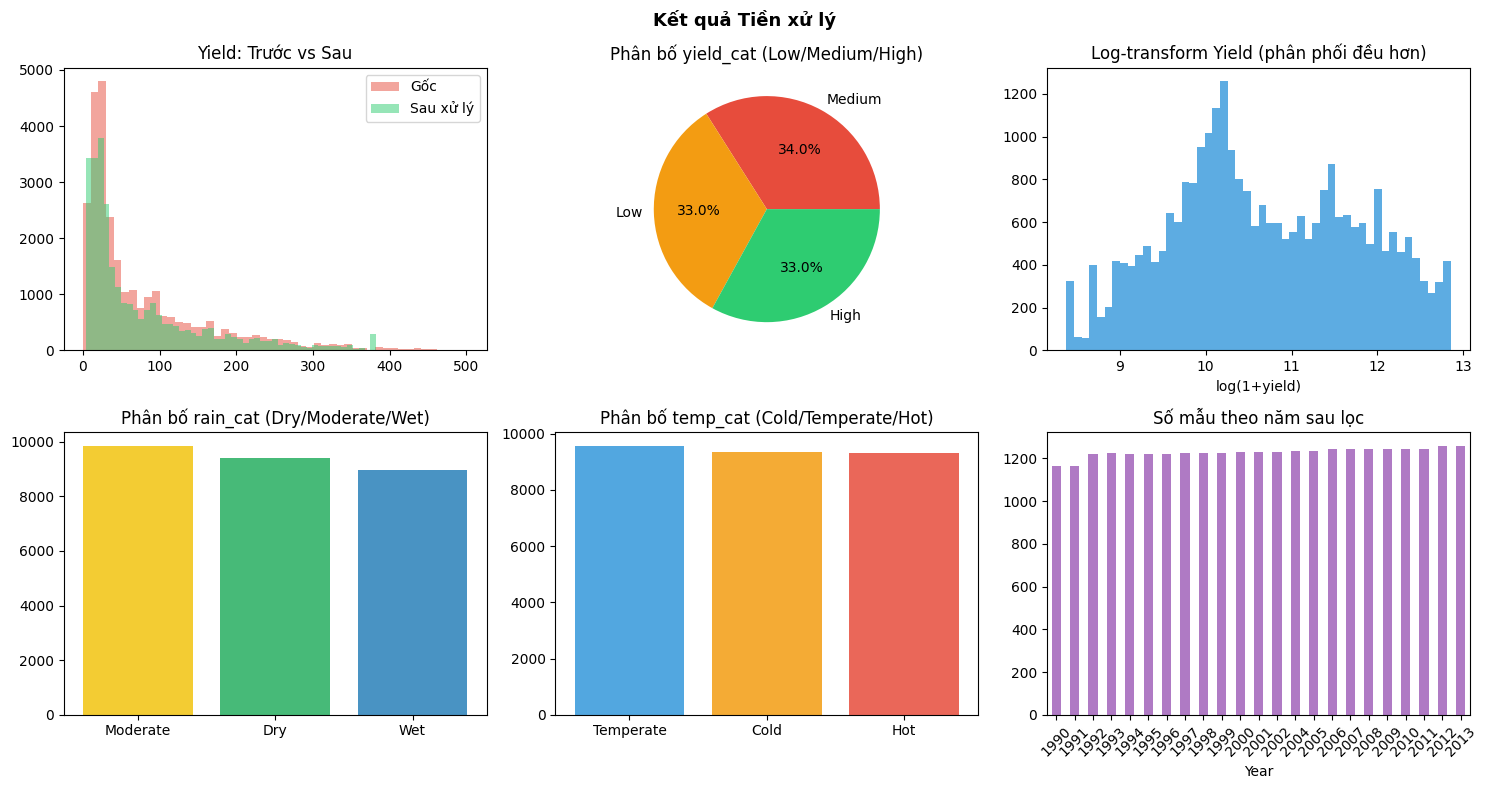

[SAVED] 03_preprocessing.png


In [8]:
raw = pd.read_csv(PROC / "crop_yield_main.csv")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Kết quả Tiền xử lý", fontsize=13, fontweight="bold")

axes[0,0].hist(raw["hg/ha_yield"]/1000, bins=50, alpha=0.5, label="Gốc", color="#e74c3c")
axes[0,0].hist(df["hg/ha_yield"]/1000, bins=50, alpha=0.5, label="Sau xử lý", color="#2ecc71")
axes[0,0].set_title("Yield: Trước vs Sau"); axes[0,0].legend()

cats = df["yield_cat"].value_counts()
axes[0,1].pie(cats.values, labels=cats.index, autopct="%1.1f%%", colors=["#e74c3c","#f39c12","#2ecc71"])
axes[0,1].set_title("Phân bố yield_cat (Low/Medium/High)")

axes[0,2].hist(df["log_yield"], bins=50, color="#3498db", alpha=0.8)
axes[0,2].set_title("Log-transform Yield (phân phối đều hơn)"); axes[0,2].set_xlabel("log(1+yield)")

rain_cats = df["rain_cat"].value_counts()
axes[1,0].bar(rain_cats.index, rain_cats.values, color=["#f1c40f","#27ae60","#2980b9"], alpha=0.85)
axes[1,0].set_title("Phân bố rain_cat (Dry/Moderate/Wet)")

temp_cats = df["temp_cat"].value_counts()
axes[1,1].bar(temp_cats.index, temp_cats.values, color=["#3498db","#f39c12","#e74c3c"], alpha=0.85)
axes[1,1].set_title("Phân bố temp_cat (Cold/Temperate/Hot)")

df.groupby("Year")["hg/ha_yield"].count().plot(kind="bar", ax=axes[1,2], color="#9b59b6", alpha=0.8)
axes[1,2].set_title("Số mẫu theo năm sau lọc"); axes[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUT / "03_preprocessing.png", dpi=100, bbox_inches="tight"); plt.show()
print("[SAVED] 03_preprocessing.png")